# embML_CL SVR-Only Workflow (Codespace)

Simplified SVR reproduction workflow extracted from embML_CL.ipynb.

## Reproducible Input Policy
- Primary feature source: Supplementary Data/S1 ML inputs and pred.xlsx
- Feature sheet: lgCL_Embeddings+RDKIT
- Single canonical input CSV saved in data_prep/lgCL_Embeddings_RDKIT_S1_full.csv

## Target Task
- Target column: lgCL
- Split tag column: CL_train_test (train/test)
- Model: Support Vector Regressor (SVR) only 


In [2]:
# Inspect new S1 data files
from pathlib import Path
import pandas as pd
for fname in ['lgCL_Embeddings_RDKIT_S1.csv', 'lgFu_Embeddings_RDKIT_S1.csv', 'lgVD_Embeddings_RDKIT_S1.csv']:
    fpath = Path('data_prep') / fname
    df = pd.read_csv(fpath, nrows=1)
    print(f"\n{fname}:")
    print(f"  Columns: {df.columns.tolist()[:20]}")
    print(f"  Total cols: {len(df.columns)}, Shape rows will be determined on full load")


lgCL_Embeddings_RDKIT_S1.csv:
  Columns: ['PUBCHEM_CID', 'CL_1', 'CL_2', 'CL_3', 'CL_4', 'CL_5', 'CL_6', 'CL_7', 'CL_8', 'CL_9', 'CL_10', 'CL_11', 'CL_12', 'CL_13', 'CL_14', 'CL_15', 'CL_16', 'CL_17', 'CL_18', 'CL_19']
  Total cols: 320, Shape rows will be determined on full load

lgFu_Embeddings_RDKIT_S1.csv:
  Columns: ['PUBCHEM_CID', 'CL_1', 'CL_2', 'CL_3', 'CL_4', 'CL_5', 'CL_6', 'CL_7', 'CL_8', 'CL_9', 'CL_10', 'CL_11', 'CL_12', 'CL_13', 'CL_14', 'CL_15', 'CL_16', 'CL_17', 'CL_18', 'CL_19']
  Total cols: 370, Shape rows will be determined on full load

lgVD_Embeddings_RDKIT_S1.csv:
  Columns: ['PUBCHEM_CID', 'CL_1', 'CL_2', 'CL_3', 'CL_4', 'CL_5', 'CL_6', 'CL_7', 'CL_8', 'CL_9', 'CL_10', 'Fu_1', 'Fu_2', 'Fu_3', 'Fu_4', 'Fu_5', 'Fu_6', 'Fu_7', 'Fu_8', 'Fu_9']
  Total cols: 250, Shape rows will be determined on full load


In [3]:
# Check all columns in lgCL file
df_cl = pd.read_csv('data_prep/lgCL_Embeddings_RDKIT_S1.csv')
print(f"lgCL file shape: {df_cl.shape}")
print(f"\nFirst 50 columns:")
print(df_cl.columns[:50].tolist())
print(f"\nLast 20 columns:")
print(df_cl.columns[-20:].tolist())
        
# Check for target and split columns
target_cols = [c for c in df_cl.columns if 'lgCL' in c or 'CL_train' in c or 'target' in c.lower()]
print(f"\nTarget/Split columns found: {target_cols}")
print(f"Total columns: {len(df_cl.columns)}")

lgCL file shape: (5620, 320)

First 50 columns:
['PUBCHEM_CID', 'CL_1', 'CL_2', 'CL_3', 'CL_4', 'CL_5', 'CL_6', 'CL_7', 'CL_8', 'CL_9', 'CL_10', 'CL_11', 'CL_12', 'CL_13', 'CL_14', 'CL_15', 'CL_16', 'CL_17', 'CL_18', 'CL_19', 'CL_20', 'CL_21', 'CL_22', 'CL_23', 'CL_24', 'CL_25', 'CL_26', 'CL_27', 'CL_28', 'CL_29', 'CL_30', 'CL_31', 'CL_32', 'CL_33', 'CL_34', 'CL_35', 'CL_36', 'CL_37', 'CL_38', 'CL_39', 'CL_40', 'CL_41', 'CL_42', 'CL_43', 'CL_44', 'CL_45', 'CL_46', 'CL_47', 'CL_48', 'CL_49']

Last 20 columns:
['fr_phos_acid', 'fr_phos_ester', 'fr_piperdine', 'fr_piperzine', 'fr_priamide', 'fr_prisulfonamd', 'fr_pyridine', 'fr_quatN', 'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene', 'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene', 'fr_unbrch_alkane', 'fr_urea', 'lgCL', 'CL_train_test']

Target/Split columns found: ['lgCL', 'CL_train_test']
Total columns: 320


In [5]:
# Check all columns in lgCL file
df_cl = pd.read_csv('data_prep/lgCL_Embeddings_RDKIT_S1.csv')
print(f"lgCL file shape: {df_cl.shape}")
print(f"\nAll columns ({len(df_cl.columns)}):")
for i, col in enumerate(df_cl.columns):
    print(f"  {i}: {col}")
    if i > 40:  # Show first 40 and check if lgCL/CL_train_test exist
        break
        
# Check for target and split columns
target_cols = [c for c in df_cl.columns if 'lgCL' in c or 'CL_train' in c]
print(f"\nTarget/Split columns found: {target_cols}")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

RANDOM_SEED = 0
TASK_COL = 'lgCL'
TAG_COL = 'CL_train_test'
ID_COL = 'PUBCHEM_CID'

WORKBOOK_PATH = Path('Supplementary Data/S1 ML inputs and pred.xlsx')
FEATURE_SHEET = 'lgCL_Embeddings+RDKIT'
META_SHEET = 'modeling_retrain_test2'
CANONICAL_INPUT_CSV = Path('data_prep/lgCL_Embeddings_RDKIT_S1_full.csv')

OUT_ROOT = Path('outputs/embML_lgCL_SVR')
OUT_ROOT.mkdir(parents=True, exist_ok=True)

sns.set_style('whitegrid')
np.random.seed(RANDOM_SEED)

print('Workbook:', WORKBOOK_PATH)
print('Canonical CSV:', CANONICAL_INPUT_CSV)
print('Output dir:', OUT_ROOT)

lgCL file shape: (5620, 320)

All columns (320):
  0: PUBCHEM_CID
  1: CL_1
  2: CL_2
  3: CL_3
  4: CL_4
  5: CL_5
  6: CL_6
  7: CL_7
  8: CL_8
  9: CL_9
  10: CL_10
  11: CL_11
  12: CL_12
  13: CL_13
  14: CL_14
  15: CL_15
  16: CL_16
  17: CL_17
  18: CL_18
  19: CL_19
  20: CL_20
  21: CL_21
  22: CL_22
  23: CL_23
  24: CL_24
  25: CL_25
  26: CL_26
  27: CL_27
  28: CL_28
  29: CL_29
  30: CL_30
  31: CL_31
  32: CL_32
  33: CL_33
  34: CL_34
  35: CL_35
  36: CL_36
  37: CL_37
  38: CL_38
  39: CL_39
  40: CL_40
  41: CL_41

Target/Split columns found: ['lgCL', 'CL_train_test']
Workbook: Supplementary Data/S1 ML inputs and pred.xlsx
Canonical CSV: data_prep/lgCL_Embeddings_RDKIT_S1_full.csv
Output dir: outputs/embML_lgCL_SVR


In [6]:
# Check new CSV file structure
df_check = pd.read_csv('data_prep/lgCL_Embeddings_RDKIT_S1.csv', nrows=2)
print("Columns:", df_check.columns.tolist()[:15])
print("Shape:", df_check.shape)
print("\nFirst row:\n", df_check.iloc[0, :5])
print("\nData types:", df_check.dtypes.head(10))# Build the canonical single CSV input from S1 workbook
if not WORKBOOK_PATH.exists():
    raise FileNotFoundError(f'Workbook not found: {WORKBOOK_PATH}')

feature_df = pd.read_excel(WORKBOOK_PATH, sheet_name=FEATURE_SHEET)
meta_df = pd.read_excel(WORKBOOK_PATH, sheet_name=META_SHEET)

required_meta_cols = [ID_COL, TASK_COL, TAG_COL]
missing_meta_cols = [c for c in required_meta_cols if c not in meta_df.columns]
if missing_meta_cols:
    raise KeyError(f'Missing required columns in {META_SHEET}: {missing_meta_cols}')

meta_df = meta_df[required_meta_cols].drop_duplicates(subset=[ID_COL])
data_df = feature_df.merge(meta_df, on=ID_COL, how='left')

CANONICAL_INPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
data_df.to_csv(CANONICAL_INPUT_CSV, index=False)

print('Saved canonical input:', CANONICAL_INPUT_CSV)
print('Shape:', data_df.shape)
print('Missing target rows:', int(data_df[TASK_COL].isna().sum()))
print('Missing split-tag rows:', int(data_df[TAG_COL].isna().sum()))

Columns: ['PUBCHEM_CID', 'CL_1', 'CL_2', 'CL_3', 'CL_4', 'CL_5', 'CL_6', 'CL_7', 'CL_8', 'CL_9', 'CL_10', 'CL_11', 'CL_12', 'CL_13', 'CL_14']
Shape: (2, 320)

First row:
 PUBCHEM_CID    15.000000
CL_1           -0.152582
CL_2           -0.157455
CL_3            0.035594
CL_4           -0.078017
Name: 0, dtype: float64

Data types: PUBCHEM_CID      int64
CL_1           float64
CL_2           float64
CL_3           float64
CL_4           float64
CL_5           float64
CL_6           float64
CL_7           float64
CL_8           float64
CL_9           float64
dtype: object
Saved canonical input: data_prep/lgCL_Embeddings_RDKIT_S1_full.csv
Shape: (5620, 320)
Missing target rows: 4156
Missing split-tag rows: 4156


In [7]:
# Load canonical input and build train/test matrices
df = pd.read_csv(CANONICAL_INPUT_CSV)

for col in [ID_COL, TASK_COL, TAG_COL]:
    if col not in df.columns:
        raise KeyError(f'Missing required column in canonical CSV: {col}')

df = df[df[TAG_COL].isin(['train', 'test'])].copy()
df = df.dropna(subset=[TASK_COL])

feature_cols = [c for c in df.columns if c not in [ID_COL, TASK_COL, TAG_COL]]
X = df[feature_cols].copy()
y = df[TASK_COL].copy()

# Feature cleaning
X = X.replace([np.inf, -np.inf], np.nan)
valid_rows = ~X.isna().any(axis=1)
X = X.loc[valid_rows]
y = y.loc[valid_rows]
df = df.loc[valid_rows]

train_mask = df[TAG_COL] == 'train'
test_mask = df[TAG_COL] == 'test'

X_train = X.loc[train_mask].values
y_train = y.loc[train_mask].values
X_test = X.loc[test_mask].values
y_test = y.loc[test_mask].values
test_ids = df.loc[test_mask, ID_COL].values

if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError('Train/Test split is empty after cleaning.')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature count:', X_train_scaled.shape[1])
print('Train size:', X_train_scaled.shape[0])
print('Test size:', X_test_scaled.shape[0])

Feature count: 317
Train size: 1284
Test size: 177


In [8]:
# Helper metrics functions
def compute_gmfe(y_true, y_pred):
    eps = 1e-10
    y_true_lin = np.maximum(10 ** y_true, eps)
    y_pred_lin = np.maximum(10 ** y_pred, eps)
    ratios = np.maximum(y_pred_lin / y_true_lin, y_true_lin / y_pred_lin)
    return float(np.exp(np.mean(np.log(ratios))))

def compute_fe(y_true, y_pred, threshold=2):
    eps = 1e-10
    y_true_lin = np.maximum(10 ** y_true, eps)
    y_pred_lin = np.maximum(10 ** y_pred, eps)
    ratios = np.maximum(y_pred_lin / y_true_lin, y_true_lin / y_pred_lin)
    return float(np.mean(ratios <= threshold))

# Train SVR with cross-validation metrics
svr_model = SVR()

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_rmse = np.sqrt(-cross_val_score(svr_model, X_train_scaled, y_train, cv=cv, scoring='neg_mean_squared_error').mean())
cv_r2 = cross_val_score(svr_model, X_train_scaled, y_train, cv=cv, scoring='r2').mean()

print(f'SVR Cross-validation metrics:')
print(f'  CV RMSE: {cv_rmse:.4f}')
print(f'  CV R2: {cv_r2:.4f}')

# Fit on full training set
svr_model.fit(X_train_scaled, y_train)
train_pred = svr_model.predict(X_train_scaled)
test_pred = svr_model.predict(X_test_scaled)

train_metrics = {
    'Set': 'Train',
    'MAE': mean_absolute_error(y_train, train_pred),
    'RMSE': np.sqrt(mean_squared_error(y_train, train_pred)),
    'R2': r2_score(y_train, train_pred),
    'GMFE': compute_gmfe(y_train, train_pred),
    'FE<2': compute_fe(y_train, train_pred, threshold=2)
}

test_metrics = {
    'Set': 'Test',
    'MAE': mean_absolute_error(y_test, test_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
    'R2': r2_score(y_test, test_pred),
    'GMFE': compute_gmfe(y_test, test_pred),
    'FE<2': compute_fe(y_test, test_pred, threshold=2)
}

metrics_summary = pd.DataFrame([train_metrics, test_metrics])
print('\nSVR Test metrics:')
print(metrics_summary.to_string())

SVR Cross-validation metrics:
  CV RMSE: 0.5482
  CV R2: 0.3416

SVR Test metrics:
     Set       MAE      RMSE        R2      GMFE      FE<2
0  Train  0.218431  0.338703  0.751373  1.653601  0.774143
1   Test  0.299762  0.408886  0.504916  1.994170  0.655367


Saved predictions: outputs/embML_lgCL_SVR/predictions_SVR.csv
Saved model: outputs/embML_lgCL_SVR/best_model_SVR.joblib
Saved metrics summary: outputs/embML_lgCL_SVR/svr_metrics_summary.csv


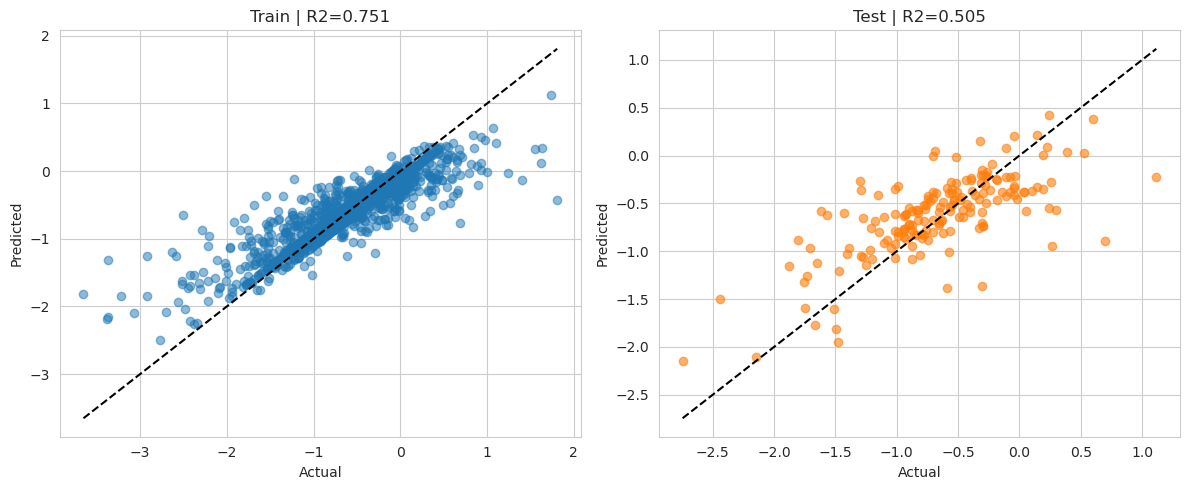

Saved plot: outputs/embML_lgCL_SVR/pred_scatter_SVR.png

========== SVR Training Complete ==========


In [9]:
# Save predictions, model artifacts, and visualization
pred_train = pd.DataFrame({
    ID_COL: df.loc[df[TAG_COL] == 'train', ID_COL].values,
    'Actual': y_train,
    'Predicted': train_pred,
    'Dataset': 'train'
})
pred_test = pd.DataFrame({
    ID_COL: test_ids,
    'Actual': y_test,
    'Predicted': test_pred,
    'Dataset': 'test'
})
pred_df = pd.concat([pred_train, pred_test], ignore_index=True)

pred_path = OUT_ROOT / 'predictions_SVR.csv'
pred_df.to_csv(pred_path, index=False)
print('Saved predictions:', pred_path)

joblib.dump({
    'model_name': 'SVR',
    'model': svr_model,
    'scaler': scaler,
    'feature_cols': feature_cols,
    'target_col': TASK_COL,
    'split_col': TAG_COL
}, OUT_ROOT / 'best_model_SVR.joblib')
print('Saved model:', OUT_ROOT / 'best_model_SVR.joblib')

# Save metrics summary
metrics_summary.to_csv(OUT_ROOT / 'svr_metrics_summary.csv', index=False)
print('Saved metrics summary:', OUT_ROOT / 'svr_metrics_summary.csv')

# Create scatter plot for predictions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_train, train_pred, alpha=0.5)
mn0, mx0 = min(y_train.min(), train_pred.min()), max(y_train.max(), train_pred.max())
axes[0].plot([mn0, mx0], [mn0, mx0], 'k--', lw=1.5)
axes[0].set_title(f'Train | R2={r2_score(y_train, train_pred):.3f}')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

axes[1].scatter(y_test, test_pred, alpha=0.6, color='tab:orange')
mn1, mx1 = min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())
axes[1].plot([mn1, mx1], [mn1, mx1], 'k--', lw=1.5)
axes[1].set_title(f'Test | R2={r2_score(y_test, test_pred):.3f}')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plot_path = OUT_ROOT / 'pred_scatter_SVR.png'
plt.savefig(plot_path, dpi=180, bbox_inches='tight')
plt.show()

print('Saved plot:', plot_path)
print('\n========== SVR Training Complete ==========')